<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download("akshatsharma2/all-in-one-dataset-for-preprocessing-practice")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'all-in-one-dataset-for-preprocessing-practice' dataset.
Path to dataset files: /kaggle/input/all-in-one-dataset-for-preprocessing-practice


# 01/

## Type of Features

In [3]:
df = pd.read_csv(f'{path}/my_data (1).csv')

df.head()

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1


In [4]:
df.shape

(1100, 7)

In [5]:
df.describe()

,age,cgpa,placed
count,982.000000,962.000000,1100.000000
mean,28.429735,7.609033,0.499091
std,9.141244,1.495991,0.500227
min,18.000000,4.010000,0.000000
25%,22.000000,7.170000,0.000000
50%,26.000000,7.925000,0.000000
75%,30.000000,8.760000,1.000000
max,50.000000,9.490000,1.000000


In [6]:
df.dtypes

,0
name,object
city,object
gender,object
profession,object
age,float64
cgpa,float64
placed,int64


In [7]:
features = {
    'nominal'  : ['name', 'city', 'gender'],
    'ordinal'  : ['profession'],
    'numerical': ['age', 'cgpa'],
    'label'    : ['placed']
}

In [8]:
missing = pd.DataFrame(index=df.columns)

missing['Null'] = df.isnull().sum()
missing['%'] = np.round(df.isnull().mean() * 100, 2)

missing

,Null,%
name,91,8.27
city,195,17.73
gender,106,9.64
profession,179,16.27
age,118,10.73
cgpa,138,12.55
placed,0,0.00


### Features Preprocessing and Transformation

In [11]:
df_transform = df.copy()

scaler = StandardScaler()
df_transform[features['numerical']] = scaler.fit_transform(df_transform[features['numerical']])

oe_nom = OrdinalEncoder()
df_transform[features['nominal']] = oe_nom.fit_transform(df_transform[features['nominal']])

prof = ['bachelor', 'masters', 'phd']
oe_ord = OrdinalEncoder(
    categories=[prof],
    handle_unknown='use_encoded_value',
    unknown_value=np.nan
)
df_transform[features['ordinal']] = oe_ord.fit_transform(df_transform[features['ordinal']])

In [12]:
df_transform.head()

,name,city,gender,profession,age,cgpa,placed
0,4.0,NaN,0.0,2.0,-0.047035,-1.116251,1
1,4.0,0.0,NaN,0.0,2.360866,0.629320,0
2,3.0,NaN,0.0,1.0,-1.141535,-1.370396,0
3,5.0,NaN,1.0,0.0,-0.375385,0.642696,1
4,5.0,NaN,1.0,0.0,-1.032085,0.769768,1


### Correlation

**Pearson Correlation Coefficient. Two Equivalent Forms**

Form 1: Computational Formula (using sums)
$$ r = \frac{\sum_{i=1}^{n} p_i q_i - n\bar{p}\bar{q}}{(n-1) s_p s_q} $$
> *Efficient for computation, especially with large datasets. Uses raw sums.*

Form 2: Definitional Formula (using deviations)
$$ r = \frac{\sum_{i=1}^{n} (p_i - \bar{p})(q_i - \bar{q})}{\sqrt{\sum_{i=1}^{n} (p_i - \bar{p})^2 \cdot \sum_{i=1}^{n} (q_i - \bar{q})^2}} $$
> *Intuitive interpretation: covariance normalized by the product of standard deviations.*

> **Note**: Both formulas are mathematically equivalent. Minor numerical differences (≤ 0.01) may arise due to floating-point precision and different order of operations.

In [13]:
# Sample ['city', 'age']

n = df.shape[0]
p = df_transform['city']
q = df_transform['age']

r1 = ( (p*q).sum() - n*p.mean()*q.mean() ) / ( (n - 1)*p.std()*q.std() )
r2 = ( (p - p.mean())*(q - q.mean()) ).sum() / ( np.sqrt( ((p - p.mean())**2).sum()*((q - q.mean())**2).sum() ) )

np.round(r1, 2), np.round(r2, 2), np.round(df_transform[['city', 'age']].corr().to_numpy()[0, 1], 2)

(np.float64(0.07), np.float64(0.06), np.float64(0.07))

Text(0.5, 1.0, 'Features Correlation')

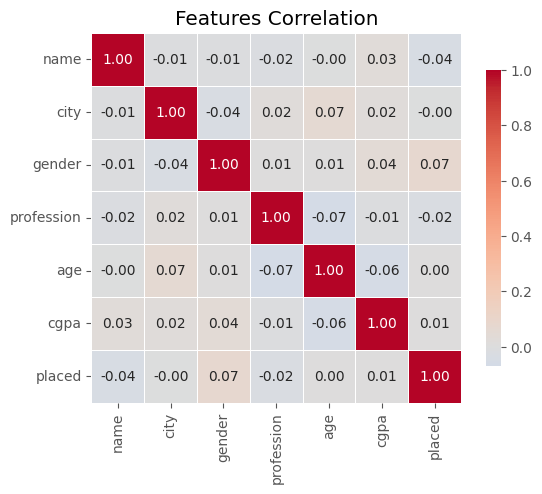

In [ ]:
sns.heatmap(df_transform.corr(),
            annot=True,
            cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})\
    .set_title('Features Correlation')

# 02/

## Missing Data Recovery

- delete object
- delete columns
- replace value

### Recovery Numerical Features using Euclidean Metrics

Distance:
$$
\rho(P, Q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$

\
Euclidean Metrics
$$
P(A) = \frac{1}{\sum_{i=1}^{n}\frac{1}{\rho(A, A_i)}}\sum_{i=1}^{n}\frac{P(A_i)}{\rho(A, A_i)}
$$


In [14]:
em = df_transform.copy()

em_scaler = StandardScaler()
em = pd.DataFrame(
    columns=em.columns,
    data=em_scaler.fit_transform(em)
)

em.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,NaN,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,NaN,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,NaN,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,NaN,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,NaN,0.554883,-0.799477,-1.032085,0.769768,1.001820


In [67]:
FULL_BASE = em.dropna() # all features are present

def get_recovery_df(column):
    recovery = em[em[column].isnull()].copy()
    recovery.drop(column, axis=1, inplace=True)
    recovery['nan'] = recovery.apply(lambda r: r[r.isna()].index.to_list(), axis=1)

    return recovery


In [93]:
em_distance = lambda p, q: ((p - q)**2).sum(axis=1)

def em_recovery(row, col_for_recvery):
    distances = em_distance(
        FULL_BASE.drop([col_for_recvery] + row['nan'], axis=1),
        row.drop('nan')
    )
    distances += 1e-10 # division-by-zero protection

    return 1 / (1 / distances).sum() * (FULL_BASE[col_for_recvery] / distances).sum()


#### Recovering Age

In [94]:
AGE_recovery = get_recovery_df('age')
AGE_recovery.head()

,name,city,gender,profession,cgpa,placed,nan
9,-1.633929,NaN,-1.802183,0.576819,0.495559,1.001820,[city]
19,1.829589,1.011774,0.554883,-0.799477,0.475495,-0.998183,[]
34,0.675083,-1.577261,NaN,NaN,-0.159866,-0.998183,"[gender, profession]"
38,0.675083,-0.714249,0.554883,-0.799477,0.174535,-0.998183,[]
70,0.097830,-0.714249,0.554883,-0.799477,-2.079325,-0.998183,[]


In [95]:
AGE_recovery['age'] = AGE_recovery.apply(em_recovery, col_for_recvery='age', axis=1)

In [96]:
AGE_recovery.head()

,name,city,gender,profession,cgpa,placed,nan,age
9,-1.633929,NaN,-1.802183,0.576819,0.495559,1.001820,[city],-0.036584
19,1.829589,1.011774,0.554883,-0.799477,0.475495,-0.998183,[],0.160776
34,0.675083,-1.577261,NaN,NaN,-0.159866,-0.998183,"[gender, profession]",-0.411851
38,0.675083,-0.714249,0.554883,-0.799477,0.174535,-0.998183,[],0.565862
70,0.097830,-0.714249,0.554883,-0.799477,-2.079325,-0.998183,[],0.012386
